In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

shl = np.load("shl_pretrain_coarse_balanced.npz", allow_pickle=True)

X = shl["X"]          # (N,125,7)
y = shl["y"]          # strings
modes = list(shl["modes"])  # should be ['train','subway','car','bus','walk'] in that order

print("X:", X.shape, "y:", y.shape)
print("modes:", modes)

mode_to_idx = {m:i for i,m in enumerate(modes)}
y_i = np.array([mode_to_idx[v] for v in y], dtype=np.int64)

# add channel dim for Conv2D input: (N,125,7,1)
X = X[..., np.newaxis].astype(np.float32)

# train/val split for SHL pretrain monitoring
rng = np.random.default_rng(42)
idx = rng.permutation(len(y_i))
split = int(0.8 * len(idx))
tr_idx, va_idx = idx[:split], idx[split:]

X_tr, y_tr = X[tr_idx], y_i[tr_idx]
X_va, y_va = X[va_idx], y_i[va_idx]

print("Train:", X_tr.shape, "Val:", X_va.shape)

X: (4030, 125, 7) y: (4030,)
modes: ['train', 'subway', 'car', 'bus', 'walk']
Train: (3224, 125, 7, 1) Val: (806, 125, 7, 1)


In [ ]:
import numpy as np

print("NaNs in X_tr:", np.isnan(X_tr).sum(), " / ", X_tr.size)
print("NaNs in X_va:", np.isnan(X_va).sum(), " / ", X_va.size)

# per-channel ranges (ax..pressure)
for k, name in enumerate(["ax","ay","az","gx","gy","gz","pressure"]):
    ch = X_tr[..., 0][:, :, k]   # (N,125)
    print(name, "min/max/mean/std:",
          float(ch.min()), float(ch.max()), float(ch.mean()), float(ch.std()))

NaNs in X_tr: 0  /  2821000
NaNs in X_va: 0  /  705250
ax min/max/mean/std: -32.68659973144531 23.897552490234375 -3.9042623043060303 5.927656173706055
ay min/max/mean/std: -16.285446166992188 34.607826232910156 2.152951717376709 2.8645288944244385
az min/max/mean/std: -20.887697219848633 36.549957275390625 0.3882701098918915 6.0621795654296875
gx min/max/mean/std: -4.2044172286987305 4.8733649253845215 0.0009952412219718099 0.22455422580242157
gy min/max/mean/std: -5.807704925537109 4.877399921417236 0.0014449667651206255 0.1680360585451126
gz min/max/mean/std: -8.051703453063965 5.386797904968262 0.0008275174768641591 0.17519201338291168
pressure min/max/mean/std: 997.445556640625 1027.6007080078125 1016.3441162109375 4.015317916870117


In [ ]:
def build_model(n_classes: int, input_shape=(125,7,1)):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(16, (5,1), activation="relu", padding="same"),
        tf.keras.layers.MaxPool2D((2,1)),
        tf.keras.layers.Conv2D(32, (5,1), activation="relu", padding="same"),
        tf.keras.layers.MaxPool2D((2,1)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(n_classes, activation="softmax")
    ])
    return model

model = build_model(n_classes=len(modes), input_shape=X_tr.shape[1:])
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 125, 7, 16)     │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 62, 7, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 62, 7, 32)      │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 7, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6944)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       444,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 447,493 (1.71 MB)

 Trainable params: 447,493 (1.71 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# X_tr and X_va are (N,125,7,1)

eps = 1e-8
mu = X_tr.mean(axis=(0,1), keepdims=True)          # shape (1,1,7,1)
sigma = X_tr.std(axis=(0,1), keepdims=True) + eps  # shape (1,1,7,1)

X_tr_z = (X_tr - mu) / sigma
X_va_z = (X_va - mu) / sigma

print("After z-score, per-channel std (approx):",
      X_tr_z[...,0].std(axis=(0,1)))

After z-score, per-channel std (approx): [1.0000148 1.0000104 0.999975  1.000001  1.0000101 1.0000024 0.847297 ]


Epoch 1/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.6557 - loss: 0.8978 - val_accuracy: 0.8772 - val_loss: 0.4200 - learning_rate: 0.0010
Epoch 2/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.8611 - loss: 0.3966 - val_accuracy: 0.9243 - val_loss: 0.3085 - learning_rate: 0.0010
Epoch 3/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.9019 - loss: 0.2896 - val_accuracy: 0.9615 - val_loss: 0.2505 - learning_rate: 0.0010
Epoch 4/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.9314 - loss: 0.2009 - val_accuracy: 0.9553 - val_loss: 0.2292 - learning_rate: 0.0010
Epoch 5/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.9468 - loss: 0.1767 - val_accuracy: 0.9603 - val_loss: 0.2432 - learning_rate: 0.0010
Epoch 6/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.9527 - loss: 0.1391 - val_accuracy: 0.9702 - val_loss: 0.2438 - learning_rate: 5.0000e-04
Epoch 7/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.9545 - loss: 0.1280 - val

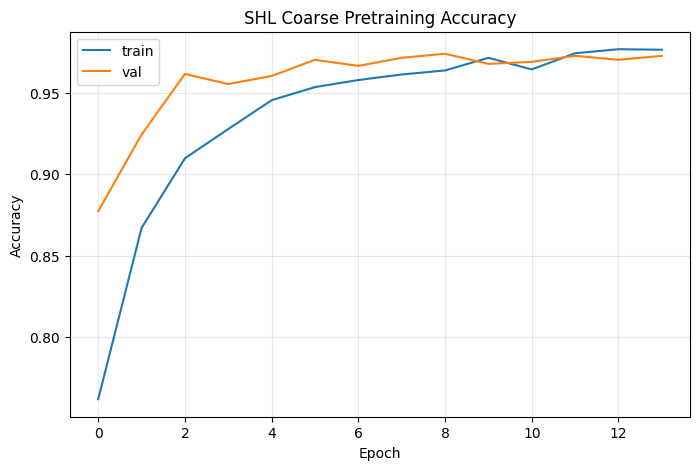

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_accuracy", factor=0.5, patience=2, min_lr=1e-5)
]

history = model.fit(
    X_tr_z, y_tr,
    validation_data=(X_va_z, y_va),
    epochs=30,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.title("SHL Coarse Pretraining Accuracy")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

SHL VAL accuracy: 0.9739
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


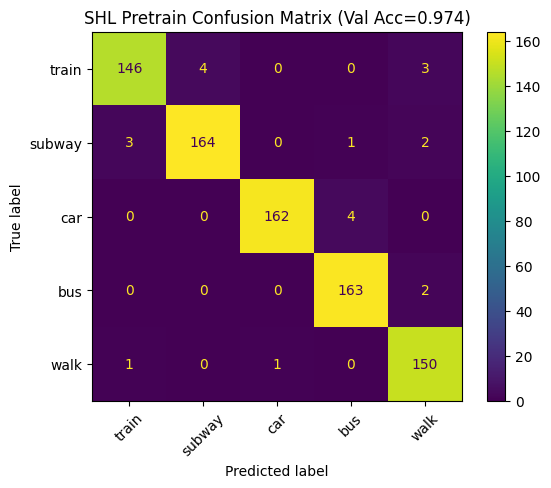

In [ ]:
val_loss, val_acc = model.evaluate(X_va_z, y_va, verbose=0)
print(f"SHL VAL accuracy: {val_acc:.4f}")

y_pred = np.argmax(model.predict(X_va_z), axis=1)
cm = confusion_matrix(y_va, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=modes)
disp.plot(cmap=None, xticks_rotation=45, values_format="d")
plt.title(f"SHL Pretrain Confusion Matrix (Val Acc={val_acc:.3f})")
plt.show()